# ML Session 2차시 과제

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

import matplotlib.pyplot as plt
%matplotlib inline

iris = pd.read_csv('Iris.csv')
adv = pd.read_csv('advertising.csv')

In [9]:
adv['Sales'].unique()

array([22.1, 10.4, 12. , 16.5, 17.9,  7.2, 11.8, 13.2,  4.8, 15.6, 12.6,
       17.4,  9.2, 13.7, 19. , 22.4, 12.5, 24.4, 11.3, 14.6, 18. , 17.5,
        5.6, 20.5,  9.7, 17. , 15. , 20.9, 18.9, 10.5, 21.4, 11.9, 17.8,
       25.4, 14.7, 10.1, 21.5, 16.6, 17.1, 20.7,  8.5, 16.1, 10.6, 23.2,
       19.8, 16.4, 10.7, 22.6, 21.2, 20.2, 23.7,  5.5, 23.8, 18.4,  8.1,
       24.2, 14. , 16. , 11. , 13.4, 22.3, 18.3, 12.4,  8.8,  8.7,  6.9,
       14.2,  5.3, 17.3, 13.6, 21.7, 12.9, 16.7,  7.3, 19.4, 22.2, 11.5,
       16.9, 17.2, 19.7, 21.8, 12.2,  9.4, 15.9,  6.6, 15.5,  7. , 15.2,
       24.7,  1.6, 17.7,  5.7, 19.6, 10.8, 11.6,  9.5, 20.8,  9.6, 10.9,
       19.2, 20.1, 12.3, 10.3, 18.2, 20.6,  3.2, 15.3, 13.3, 19.9,  8. ,
       20. ,  8.4,  7.6, 27. , 16.8, 17.6, 26.2,  6.7,  5.9, 14.8, 25.5])

### 문제 1 (24점)
#### 1-1. 분류 평가지표 중 '정밀도'와 '재현율'에 대한 개념과 이 둘이 어떤 관계인지 설명해주세요. (6점)

정밀도는 분류 평가지표 중 하나로 Positive로 예측한 것 중 진짜 Positive의 비율이다. (TP / TP+FP)  
재현율도 분류 평가지표 중 하나로 진짜 Positive 중 Positive로 예측한 것의 비율이다. (TP / TP+FN)  
정밀도와 재현율은은 서로 트레이드오프 관계로 상충관계이다.

#### 1-2.  '정밀도'와 '재현율'의 관계로 인하여 다른 어떤 평가지표를 쓰는 것이 좋은가요? 그 이유와 함께 설명해주세요. (6점)

F1-score를 쓰는 것이 좋다.  
F1-score는 정밀도와 재현율의 조화평균으로, 두 값이 비슷할 때 높은 값을 가진다.

#### 1-3. 정밀도와 재현율이 각각 더 중요한 사례를 적어주세요. (각 6점)
- 되도록 ppt에 나온 사례 외의 사례를 들어주세요

#### 정밀도가 더 중요한 경우
금융사기탐지: 정상적인 거래를 잘못된 거래로 판단하면 안되므로 정밀도가 중요하다.

#### 재현율이 더 중요한 경우
재난경보시스템: 실제 재난 상황을 놓치면 대규모 피해가 있을 수 있어서 재현율이 중요하다.

### 문제2 (40점)
#### 2-1. (20점) 
**Stratified K-fold Cross Validation은 회귀에서는 지원되지 않지만 <font color="#CC3D3D">임의로 범주형 데이터로 쪼개서</font> Stratified K-fold를 사용할 수 있습니다.   
`adv`데이터를 사용하여 Strtifed K-fold를 적용해보세요.**  
- `Sales` 값에 따라 임의로 범주형을 부여합니다.  
- 임의로 부여한 범주형에 따라 Stratifed K-fold를 적용합니다.  
※ 임의로 부여한 범주형과 데이터 갯수를 출력해주세요.

In [15]:
# code here
# 범주형 변환
adv['NSales']=adv['Sales'].apply(lambda x : 'High' if x >= 20 else 'Middle' if x >= 10 else 'Low')

# Stratifed K-fold 적용
kfold_Sales = StratifiedKFold(n_splits=3)
cnt_iter = 0 
for train_idx, test_idx in kfold_Sales.split(adv, adv['NSales']): 
    cnt_iter += 1
    label_train = adv['NSales'].iloc[train_idx]
    label_test = adv['NSales'].iloc[test_idx]
    
    print('** 교차검증: {} **'.format(cnt_iter))
    print('학습 레이블 데이터 분포 : \n' , label_train.value_counts())
    print('검증 레이블 데이터 분포 : \n' , label_test.value_counts())
    print('\n')

** 교차검증: 1 **
학습 레이블 데이터 분포 : 
 NSales
Middle    84
High      26
Low       23
Name: count, dtype: int64
검증 레이블 데이터 분포 : 
 NSales
Middle    42
High      14
Low       11
Name: count, dtype: int64


** 교차검증: 2 **
학습 레이블 데이터 분포 : 
 NSales
Middle    84
High      27
Low       22
Name: count, dtype: int64
검증 레이블 데이터 분포 : 
 NSales
Middle    42
High      13
Low       12
Name: count, dtype: int64


** 교차검증: 3 **
학습 레이블 데이터 분포 : 
 NSales
Middle    84
High      27
Low       23
Name: count, dtype: int64
검증 레이블 데이터 분포 : 
 NSales
Middle    42
High      13
Low       11
Name: count, dtype: int64




#### 2-2. (20점)
- 2-1에서 사용한 Stratified K-fold를 적용하세요.  
- DecisionTreeRegressor를 사용하세요.  <font color="#CC3D3D">(Hint! for문 안에 사용)</font>   
- 각 fold별로 MAE와 MAPE를 출력하세요.<font color="#CC3D3D">(Hint! for문 안에 사용)</font>   
- 각 fold의 성능을 평균내어 모델의 MAE와 MAPE를 출력하세요.<font color="#CC3D3D">(Hint! 각 fold의 지표를 담을 빈 리스트 생성)</font>

In [25]:
# code here
kfold_Sales = StratifiedKFold(n_splits=3)
cnt_iter = 0 
mae_l=[]
mape_l=[]
for train_idx, test_idx in kfold_Sales.split(adv, adv['NSales']): 
    cnt_iter += 1
    # 훈련, 테스트 데이터 생성
    X_train = adv.iloc[train_idx].drop(columns=['NSales'])
    X_test = adv.iloc[test_idx].drop(columns=['NSales'])
    y_train = adv['Sales'].iloc[train_idx]
    y_test = adv['Sales'].iloc[test_idx]
    # 모델 만들기
    model = DecisionTreeRegressor()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    # MAE, MAPE 생성
    MAE = mean_absolute_error(y_test, pred)
    MAPE = np.mean(np.abs((y_test - pred) / y_test)) * 100
    # 리스트에 추가
    mae_l.append(MAE)
    mape_l.append(MAPE)
    
    print('** 교차검증: {} **'.format(cnt_iter))
    print('MAE : {}'.format(MAE) )
    print('MAPE : {}'.format(MAPE))
    print('\n')
    
# 평균 만들기
mae_mean = np.mean(mae_l)
mape_mean = np.mean(mape_l)
print('MAE 평균 : {}'.format(mae_mean))
print('MAPE 평균 : {}'.format(mape_mean))

** 교차검증: 1 **
MAE : 0.11044776119402991
MAPE : 0.8739789874766144


** 교차검증: 2 **
MAE : 0.19552238805970165
MAPE : 2.923594685978793


** 교차검증: 3 **
MAE : 0.18484848484848504
MAPE : 1.9683959254007333


MAE 평균 : 0.16360621136740552
MAPE 평균 : 1.9219898662853803


### 문제 3 (12점, 각 6점)
#### 3-1.
**<font color="#CC3D3D">"보험 사기 적발 모델"</font>은 <font color="#CC3D3D">금융 사기 거래인지, 정상  거래인지 판단하는 모델</font>입니다.   
해당 모델의 평가지표로 어떤 평가지표가 사용되는 것이 좋을까요?   
평가지표와 그 이유를 작성해주세요.**

재현율이 사용되는 것이 좋다.  
실제로 금융사기인데 아니라고 판단하게 되면 큰 피해를 입을 수 있으므로 재현율이 사용되야 한다.

#### 3-2.
암 예측 모델에서는 실제 암환자(Positive)를 일반인(Negative)라고 판단할 경우 업무상 큰 영향이 있기 때문에 재현율(Recall)을 평가지표로 사용하는 것이 바람직합니다.
  
  
**임계값을 낮추면 재현율을 높일 수 있는데요. <font color="#CC3D3D">임계값을 낮추어 재현율을 높이는 것은 바람직하지 않습니다.</font>  
해당 모델의 경우 왜 바람직하지 않은지 작성해주세요.**

임계값을 낮추게 되면 양성으로 판단하게 될 가능성이 커지는데, 이렇게 되면 실제 암환자가 아닌데도 암이라고 판단 할 가능성이 있다.  
즉 정밀도가 낮아지게 되어서 임계값을 낮추어 재현율을 높이는 것은 바람직하지 않다.   

### 문제 4 (12점)
#### confusion_matrix의 TN, FP, FN, TP를 사용하여 accuracy(정확도), precision(정밀도), recall(재현율)을 구하는 함수를 만들어주세요.

#### code here
acc = (TN + TP) / (TN+FP+FN+TP)  
pre = TP / (TP+FP)  
rec = TP / (TP+FN)

### 문제 5 (12점, 각 6점)
#### 배우지 않은 회귀 평가지표 2가지 이상을 찾아 <font color="#CC3D3D">평가지표명, 수식, 장단점, 한계</font>등 평가지표에 대한 설명을 작성해주세요.

1. MSLE (Mean Squared Log Error)  
MSE에 로그를 적용해준 지표  
장점: 작은 값의 오차에 관대, 비율 기반 비교에 유용  
단점 및 한계: 음수 값 처리 불가, 작은 값의 오차 무시

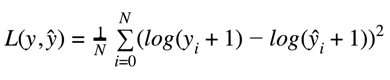

In [8]:
from IPython.display import Image
Image(r"C:\Users\touch\OneDrive\바탕 화면/1.png")

2. RMSLE (Root Mean Squared Log Error)  
RMSE에 로그를 적용해준 지표입니다.  
장점: 큰 오차의 영향 완화, 비율 기반 평가  
단점 및 한계: 절대 오차에 덜 민감, 음수 값 처리 불가

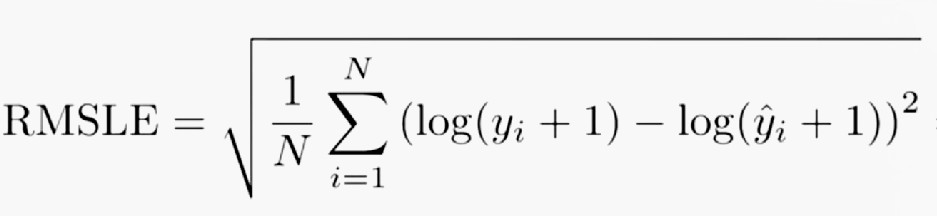

In [15]:
Image(r"C:\Users\touch\OneDrive\바탕 화면/2.jpg", width=400, height=400)